# 🏠 House Prices — Classificação
**Responsável:** Emanuel  
**Dataset:** [Kaggle - House Prices: Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data)  
**Objetivo:** Transformar `SalePrice` em uma variável binária e comparar dois classificadores — **Regressão Logística** e **Random Forest** — usando Accuracy, Precision, Recall, F1-Score e Matriz de Confusão.

---

## 📦 0. Setup — Importações, Carregamento e Pré-processamento

Importamos as bibliotecas e carregamos o `train_processed.csv` (gerado pelo notebook 01).
Este dataset já possui as variáveis numéricas normalizadas, valores nulos imputados e variáveis categóricas processadas (One-Hot Encoding), nos poupando do trabalho de pré-processamento manual aqui.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


In [2]:
# Carrega o dataset processado pelo notebook 01
df = pd.read_csv(r'..\data\train_processed.csv')

print(f'Shape do dataset: {df.shape}')
print(f'\nPrimeiras linhas:')
df.head()

Shape do dataset: (1458, 298)

Primeiras linhas:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SalePrice
0,1,0.073426,-0.221328,-0.203934,0.658506,-0.517649,1.052959,0.880362,0.523937,0.617283,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,208500
1,2,-0.871868,0.491760,-0.087252,-0.068293,2.177825,0.158428,-0.428115,-0.570739,1.245719,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,181500
2,3,0.073426,-0.078710,0.080162,0.658506,-0.517649,0.986698,0.831900,0.334044,0.108989,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,223500
3,4,0.309749,-0.459024,-0.092325,0.658506,-0.517649,-1.862551,-0.718888,-0.570739,-0.514826,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,140000
4,5,0.073426,0.681917,0.385566,1.385305,-0.517649,0.953567,0.734975,1.384039,0.499451,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,250000


In [3]:
# O dataset processado já tem todas as features prontas (numéricas escaladas + OHE)
# Vamos remover apenas a coluna Id, que não é útil para predição
df_num = df.drop(columns=['Id']).copy()

print(f'Colunas disponíveis para modelagem: {df_num.shape[1]}')
print(f'Valores nulos restantes: {df_num.isnull().sum().sum()}')
df_num.head()

Colunas disponíveis para modelagem: 297
Valores nulos restantes: 0


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SalePrice
0,0.073426,-0.221328,-0.203934,0.658506,-0.517649,1.052959,0.880362,0.523937,0.617283,-0.288867,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,208500
1,-0.871868,0.491760,-0.087252,-0.068293,2.177825,0.158428,-0.428115,-0.570739,1.245719,-0.288867,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,181500
2,0.073426,-0.078710,0.080162,0.658506,-0.517649,0.986698,0.831900,0.334044,0.108989,-0.288867,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,223500
3,0.309749,-0.459024,-0.092325,0.658506,-0.517649,-1.862551,-0.718888,-0.570739,-0.514826,-0.288867,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,140000
4,0.073426,0.681917,0.385566,1.385305,-0.517649,0.953567,0.734975,1.384039,0.499451,-0.288867,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,250000


## Carregamendo Df com coluna SalePrice

In [4]:
print(f'\nPrimeiras linhas:')
df_num[['SalePrice']].head()


Primeiras linhas:


,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000


---
## Criação da Variável Alvo Binária (`SalePrice_bin`)

Transformamos `SalePrice` em uma variável binária baseada na **mediana**:
- `1` → imóvel **caro** (SalePrice ≥ mediana)
- `0` → imóvel **barato** (SalePrice < mediana)

Essa abordagem garante um balanceamento natural entre as classes (~50%/50%).

In [5]:
# Calcula a mediana de SalePrice
mediana_preco = df_num['SalePrice'].median()
print(f'Mediana de SalePrice: ${mediana_preco:,.2f}')

# Cria a variável binária
df_num['SalePrice_bin'] = (df_num['SalePrice'] >= mediana_preco).astype(int)

# Distribuição da nova variável
contagem = df_num['SalePrice_bin'].value_counts().rename({0: 'Barato (0)', 1: 'Caro (1)'})
proporcao = df_num['SalePrice_bin'].value_counts(normalize=True).rename({0: 'Barato (0)', 1: 'Caro (1)'})

dist_df = pd.DataFrame({'Contagem': contagem, 'Proporção (%)': (proporcao * 100).round(2)})
print('\nDistribuição de SalePrice_bin:')
print(dist_df.to_string())

Mediana de SalePrice: $163,000.00

Distribuição de SalePrice_bin:
               Contagem  Proporção (%)
SalePrice_bin                         
Caro (1)            731          50.14
Barato (0)          727          49.86


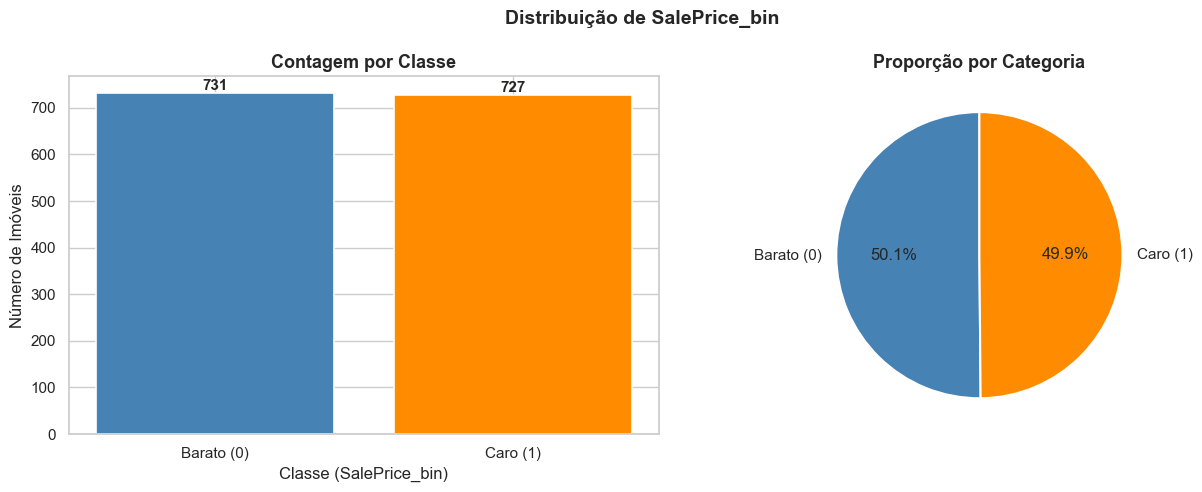

✅ Gráfico salvo: plot_distribuicao_target.png


In [6]:
# ── Visualização da distribuição ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico de barras (Count por categoria)
bars = axes[0].bar(
    ['Barato (0)', 'Caro (1)'],
    contagem.values,
    color=['steelblue', 'darkorange'],
    edgecolor='white', linewidth=1.2
)
for bar, val in zip(bars, contagem.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 8, str(val), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Contagem por Classe', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de Imóveis')
axes[0].set_xlabel('Classe (SalePrice_bin)')

# Gráfico de pizza — proporção
axes[1].pie(
    proporcao.values,
    labels=['Barato (0)', 'Caro (1)'],
    autopct='%1.1f%%',
    colors=['steelblue', 'darkorange'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Proporção por Categoria', fontsize=13, fontweight='bold')

plt.suptitle('Distribuição de SalePrice_bin', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/plot_distribuicao_target.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo: plot_distribuicao_target.png')

## Separação Treino/Teste e Preparação das Features

In [7]:
# Remove SalePrice (original) e SalePrice_bin (alvo) das features
TARGET = 'SalePrice_bin'
X = df_num.drop(columns=['SalePrice', 'SalePrice_bin'])
y = df_num[TARGET]

# Divisão 80/20 com random_state=42 (reprodutibilidade)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y  # stratify garante proporção igual em treino e teste
)

print(f'Total de amostras:   {len(df_num)}')
print(f'Treino (80%):        {len(X_train)}')
print(f'Teste  (20%):        {len(X_test)}')
print(f'\nProporção no treino:  {y_train.value_counts(normalize=True).to_dict()}')
print(f'Proporção no teste:   {y_test.value_counts(normalize=True).to_dict()}')




Total de amostras:   1458
Treino (80%):        1166
Teste  (20%):        292

Proporção no treino:  {1: 0.5017152658662093, 0: 0.49828473413379076}
Proporção no teste:   {1: 0.5, 0: 0.5}


## Treinamento dos Modelos

### Regressão Logística

| Hiperparâmetro | Valor | Justificativa |
|---|---|---|
| `C` | 1.0 | Regularização padrão (compromisso entre viés e variância) |
| `solver` | `lbfgs` | Eficiente para datasets de tamanho médio |
| `max_iter` | 1000 | Garante convergência com dados normalizados |
| `random_state` | 42 | Reprodutibilidade |

In [8]:
#Regressão Logística
# Usa dados normalizados (X_train)
lr = LogisticRegression(
    C=1.0,           # inverso da força de regularização L2
    solver='lbfgs',  # otimizador eficiente para datasets médios
    max_iter=1000,   # iterações máximas para convergência
    random_state=42
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('Regressão Logística treinada')
print(f'Hiperparâmetros: C={lr.C}, solver="{lr.solver}", max_iter={lr.max_iter}')

Regressão Logística treinada
Hiperparâmetros: C=1.0, solver="lbfgs", max_iter=1000


### Random Forest

| Hiperparâmetro | Valor | Justificativa |
|---|---|---|
| `n_estimators` | 200 | Essa quantidade permite boa estabilidade sem processamento excessivo |
| `max_depth` | 10 | Limita profundidade para evitar overfitting |
| `min_samples_split` | 5 | Evita splits em grupos muito pequenos |
| `class_weight` | `balanced` | Compensa possível desbalanceamento residual |
| `random_state` | 42 | Reprodutibilidade |

In [9]:
# Random Forest
# Não precisa de normalização
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,          
    min_samples_split=5,   
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1              
)
rf.fit(X_train, y_train)   
y_pred_rf = rf.predict(X_test)

print('Random Forest treinado')
print(f'Hiperparâmetros: n_estimators={rf.n_estimators}, max_depth={rf.max_depth}, '
      f'min_samples_split={rf.min_samples_split}, class_weight="{rf.class_weight}"')

Random Forest treinado
Hiperparâmetros: n_estimators=200, max_depth=10, min_samples_split=5, class_weight="balanced"


## Comparação dos Modelos

Métricas utilizadas nessa avaliação:

| Métrica | O que mede |
|---|---|
| **Accuracy** | % total de predições corretas |
| **Precision** | Dos previstos como *caros*, quantos realmente são? |
| **Recall** | Dos realmente *caros*, quantos foram corretamente identificados? |
| **F1-Score** | Média harmônica de Precision e Recall (balanceia os dois) |

In [10]:
def calcular_metricas_clf(y_real, y_pred, nome_modelo):
    acc  = accuracy_score(y_real, y_pred)
    prec = precision_score(y_real, y_pred)
    rec  = recall_score(y_real, y_pred)
    f1   = f1_score(y_real, y_pred)

    print(f'\n{"="*50}')
    print(f'  {nome_modelo}')
    print(f'{"="*50}')
    print(f'  Accuracy:   {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision:  {prec:.4f}')
    print(f'  Recall:     {rec:.4f}')
    print(f'  F1-Score:   {f1:.4f}')
    print(f'\n  Resultados:')
    print(classification_report(y_real, y_pred, target_names=['Barato (0)', 'Caro (1)']))

    return {'Modelo': nome_modelo, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

## Comparando os dois modelos

In [11]:
m_lr = calcular_metricas_clf(y_test, y_pred_lr, 'Regressão Logística')


  Regressão Logística
  Accuracy:   0.9212  (92.12%)
  Precision:  0.9128
  Recall:     0.9315
  F1-Score:   0.9220

  Resultados:
              precision    recall  f1-score   support

  Barato (0)       0.93      0.91      0.92       146
    Caro (1)       0.91      0.93      0.92       146

    accuracy                           0.92       292
   macro avg       0.92      0.92      0.92       292
weighted avg       0.92      0.92      0.92       292



In [12]:
m_rf = calcular_metricas_clf(y_test, y_pred_rf, 'Random Forest')


  Random Forest
  Accuracy:   0.9178  (91.78%)
  Precision:  0.9420
  Recall:     0.8904
  F1-Score:   0.9155

  Resultados:
              precision    recall  f1-score   support

  Barato (0)       0.90      0.95      0.92       146
    Caro (1)       0.94      0.89      0.92       146

    accuracy                           0.92       292
   macro avg       0.92      0.92      0.92       292
weighted avg       0.92      0.92      0.92       292



### Matrizes de Confusão

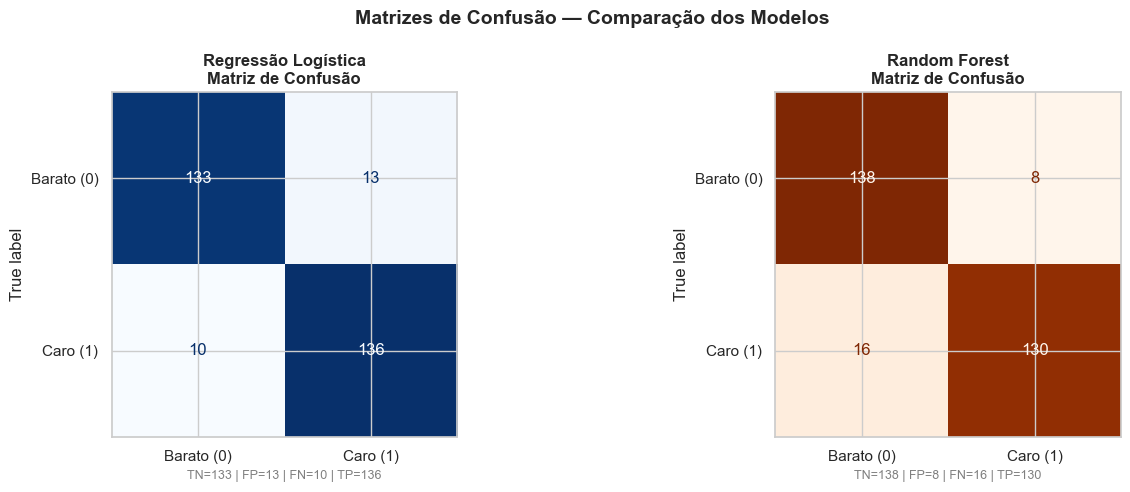

✅ Gráfico salvo: plot_confusion_matrix.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos_conf = [
    (y_pred_lr, 'Regressão Logística', 'Blues'),
    (y_pred_rf, 'Random Forest',       'Oranges'),
]

for ax, (y_pred, titulo, cmap) in zip(axes, modelos_conf):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Barato (0)', 'Caro (1)']
    )
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{titulo}\nMatriz de Confusão', fontsize=12, fontweight='bold')

    # Anotação explicativa
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(
        f'TN={tn} | FP={fp} | FN={fn} | TP={tp}',
        fontsize=9, color='gray'
    )

plt.suptitle('Matrizes de Confusão — Comparação dos Modelos',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/plot_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo: plot_confusion_matrix.png')

## Tabela de comparação

In [14]:
comparativo = pd.DataFrame([m_lr, m_rf]).set_index('Modelo')
comparativo = comparativo.round(4)

print('\nTABELA COMPARATIVA — MÉTRICAS DOS MODELOS')
print('='*65)
print(comparativo.to_string())
print('='*65)

# Identifica o melhor modelo por métrica
print('\nMelhor modelo por métrica:')
for col in comparativo.columns:
    melhor = comparativo[col].idxmax()
    valor = comparativo[col].max()
    print(f'  {col:<12} → {melhor}  ({valor:.4f})')


TABELA COMPARATIVA — MÉTRICAS DOS MODELOS
                     Accuracy  Precision  Recall  F1-Score
Modelo                                                    
Regressão Logística    0.9212     0.9128  0.9315    0.9220
Random Forest          0.9178     0.9420  0.8904    0.9155

Melhor modelo por métrica:
  Accuracy     → Regressão Logística  (0.9212)
  Precision    → Random Forest  (0.9420)
  Recall       → Regressão Logística  (0.9315)
  F1-Score     → Regressão Logística  (0.9220)


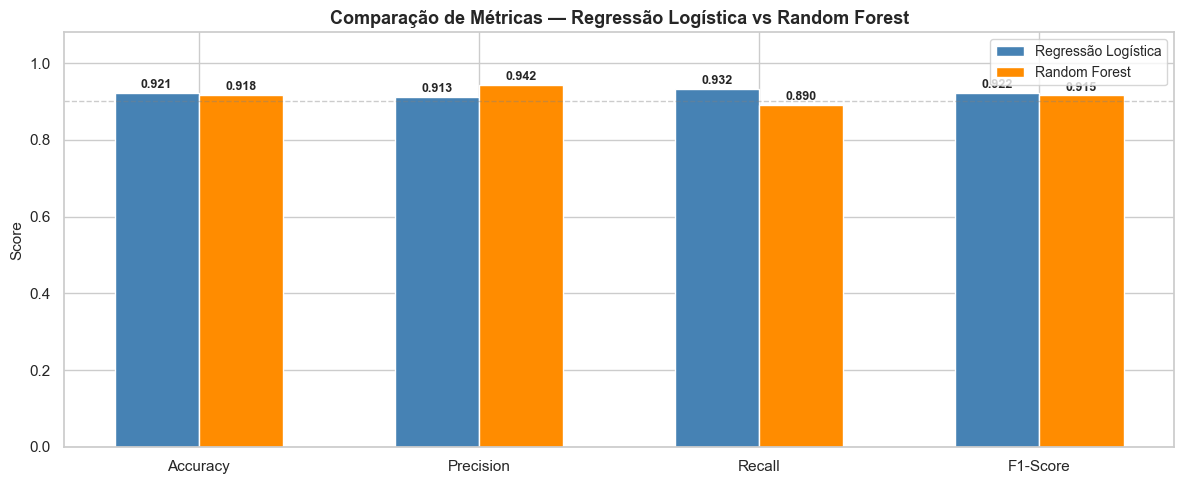

Gráfico salvo: plot_comparativo_metricas_clf.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

metricas_nomes = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metricas_nomes))
largura = 0.3

bars_lr = ax.bar(x - largura/2,
                 [m_lr[m] for m in metricas_nomes],
                 largura, label='Regressão Logística', color='steelblue', edgecolor='white')
bars_rf = ax.bar(x + largura/2,
                 [m_rf[m] for m in metricas_nomes],
                 largura, label='Random Forest', color='darkorange', edgecolor='white')

# Rótulos de valor nas barras
for bar in list(bars_lr) + list(bars_rf):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metricas_nomes, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Comparação de Métricas — Regressão Logística vs Random Forest',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.4, linewidth=1)

plt.tight_layout()
plt.savefig('../plots/plot_comparativo_metricas_clf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: plot_comparativo_metricas_clf.png')

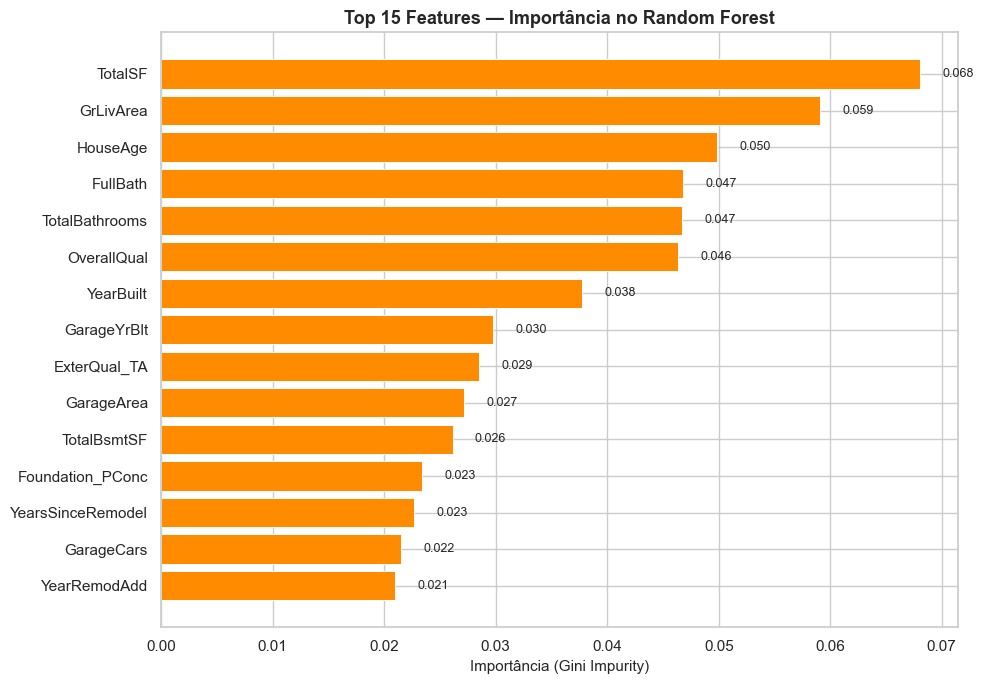

Gráfico salvo: plot_feature_importance.png


In [16]:
# Principais Features pro Random Forest
importancias = pd.Series(rf.feature_importances_, index=X.columns)
top15 = importancias.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15.index, top15.values, color='darkorange', edgecolor='white', linewidth=0.7)

for bar, val in zip(bars, top15.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Top 15 Features — Importância no Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importância (Gini Impurity)', fontsize=11)
plt.tight_layout()
plt.savefig('../plots/plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: plot_feature_importance.png')

In [17]:
melhor_f1    = 'Random Forest' if m_rf['F1-Score'] > m_lr['F1-Score'] else 'Regressão Logística'
melhor_acc   = 'Random Forest' if m_rf['Accuracy'] > m_lr['Accuracy'] else 'Regressão Logística'
diff_f1      = abs(m_rf['F1-Score'] - m_lr['F1-Score'])
diff_acc     = abs(m_rf['Accuracy'] - m_lr['Accuracy'])

print('=' * 60)
print('INTERPRETAÇÃO DOS RESULTADOS')
print('=' * 60)

print(f"""
Melhor modelo por F1-Score:  {melhor_f1}
   Diferença de F1-Score:       {diff_f1:.4f} pontos

Melhor modelo por Accuracy:  {melhor_acc}
   Diferença de Accuracy:       {diff_acc:.4f} pontos ({diff_acc*100:.2f}%)

Por que o {melhor_f1} se sai melhor?
──────────────────────────────────────────────────────
→ Random Forest é um modelo de conjunto (ensemble) que combina
  múltiplas árvores de decisão, capturando relações não-lineares
  e interações entre features que a Regressão Logística (modelo
  linear) não consegue representar diretamente.

→ Preços de imóveis envolvem interações complexas (ex: tamanho
  × localização × ano de construção), o que favorece modelos
  baseados em árvores.

→ A Regressão Logística, por sua vez, é mais interpretável e
  robusta quando o número de amostras é pequeno ou as features
  são bem separáveis linearmente.
""")
print('=' * 60)

INTERPRETAÇÃO DOS RESULTADOS

Melhor modelo por F1-Score:  Regressão Logística
   Diferença de F1-Score:       0.0065 pontos

Melhor modelo por Accuracy:  Regressão Logística
   Diferença de Accuracy:       0.0034 pontos (0.34%)

Por que o Regressão Logística se sai melhor?
──────────────────────────────────────────────────────
→ Random Forest é um modelo de conjunto (ensemble) que combina
  múltiplas árvores de decisão, capturando relações não-lineares
  e interações entre features que a Regressão Logística (modelo
  linear) não consegue representar diretamente.

→ Preços de imóveis envolvem interações complexas (ex: tamanho
  × localização × ano de construção), o que favorece modelos
  baseados em árvores.

→ A Regressão Logística, por sua vez, é mais interpretável e
  robusta quando o número de amostras é pequeno ou as features
  são bem separáveis linearmente.

